# Infering the profile of the DosR motif and finding all its putative occurrences in _Mycobacterium tuberculosis_
### _Santiago Wilders Azara - 2026_ 

---

This notebook documents the exploration of the challenge problem closing Chapter 2 of *Bioinformatics Algorithms: An Active Learning Approach*. The objective is to use motif search algorithms to find the profile of the DosR motif and all its putative occurrences in *Mycobacterium tuberculosis*. The **dormancy survival regulator (DosR)** is a transcription factor that regulates many genes whose expression changes dramatically 
under hypoxic conditions. A DNA microarray experiment identified 25 genes with significantly altered expression levels under hypoxia. We apply motif search algorithms to the upstream regions of 10 of these genes to find an appropriate profile matrix for the DosR motif.

## 1. Utility Functions

In [1]:
import sys
sys.path.append("../")
import time
import motif_utils as mu
import json
import matplotlib.pyplot as plt

#### motif_utils provides the following functions:

- **hamming_distance** - computes the Hamming distance between two strings of equal length.
- **score_consensus** - scores a set of motifs as the total number of mismatches with the column-wise consensus.
- **score_entropy** - scores a set of motifs as the sum of Shannon entropies across columns.
- **profile_matrix** - builds a (4 × k) probability matrix from a set of motifs using Laplace pseudocounts.
- **profile_most_probable_kmer** - returns the k-mer in a sequence with the highest probability under a profile matrix.
- **number_to_pattern** - converts an integer index to its corresponding DNA k-mer.
- **median_string** - finds the k-mer that minimizes the total Hamming distance to a set of DNA sequences.
- **greedy_motif_search** - greedy motif search with pseudocounts and interchangeable scoring function.
- **randomized_motif_search** - single run of the randomized motif search (Monte Carlo), iteratively improves from a random starting set.
- **gibbs_sampler** - Gibbs sampler for motif finding, probabilistically resamples one motif per iteration over N rounds.
- **consensus_from_motifs** - Returns the motif consensus based on a set of same lenght motifs.

## 2. Data

- **DosR.txt** - contains the upstream regions of 10 genes with significantly altered expression levels under hypoxic conditions in *Mycobacterium tuberculosis*.
- **Mycobacterium_tuberculosis_H37Rv_sequence.fasta** - the complete genome of *M. tuberculosis* H37Rv ([RefSeq accession NC_000962.3](https://www.ncbi.nlm.nih.gov/nuccore/NC_000962.3?report=fasta)).

In [2]:
from Bio import SeqIO

ruta_fna = "Mycobacterium_tuberculosis_H37Rv_sequence.fasta"
data_iterator = SeqIO.parse(ruta_fna, "fasta")

for register in data_iterator:
    print(register)
    print(f"Length: {len(register.seq)} bp")
    print("-" * 100)

ID: NC_000962.3
Name: NC_000962.3
Description: NC_000962.3 Mycobacterium tuberculosis H37Rv, complete genome
Number of features: 0
Seq('TTGACCGATGACCCCGGTTCAGGCTTCACCACAGTGTGGAACGCGGTCGTCTCC...TCG')
Length: 4411532 bp
----------------------------------------------------------------------------------------------------


The first and only sequence **NC_000962.3** is the genome we are going to work with.

**mtb_genome** will be the complete genome in string format, and **dna_strings** will be the 10 genes with altered expression, as a list of strings.

In [3]:
data_iterator = SeqIO.parse(ruta_fna, "fasta")
register = next(data_iterator)
mtb_genome = str(register.seq).upper()

In [4]:
with open("DosR.txt", "r") as f:
    dna_strings = [line.strip() for line in f if line.strip()]

print(f"Sequences loaded: {len(dna_strings)}")

Sequences loaded: 10


## 3. Searching for the DosR Binding Motif

We test multiple values of *k* (motif length) using several complementary algorithms: **Median String**, **Greedy Motif Search**, **Randomized Motif Search**, and **Gibbs Sampler** in order to identify the length and sequence of the DosR binding motif.

### 3.1 Median String

The Median String algorithm exhaustively finds the *k*-mer that minimises the total Hamming distance to all input sequences. Because its runtime grows exponentially with *k* (O(4^k · n · L)).

In [5]:
med_motifs_list = []
start_time = time.time()
med_motifs_list.append(mu.median_string(7, dna_strings))
print(f"--- k = {7} | {time.time() - start_time:.2f} seconds ---")

--- k = 7 | 18.07 seconds ---


In [6]:
print(med_motifs_list)

['ACCGACG']


Running the Median String algorithm in Python is **extremely slow**, as can be seen.

It has been re-implemented in C++ (median_string.cpp) and will be defined as a new function and run from here as a subprocess.

In [7]:
import subprocess
import tempfile
import os

def median_string_cpp(k: int, dna_strings: list) -> str:
    """
    Requires compiling median_string.cpp first:
        g++ -O2 -o median_string median_string.cpp
    """
    # Write input to a temporary file
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        f.write(f"{k}\n")
        f.write("\n".join(dna_strings))
        tmp_path = f.name

    try:
        result = subprocess.run(
            ["./median_string", tmp_path],
            capture_output=True,
            text=True,
            check=True
        )
        return result.stdout.strip()
    except subprocess.CalledProcessError as e:
        print(f"Error: {e.stderr}")
        return ""
    finally:
        os.unlink(tmp_path)  # delete temp file regardless of outcome

In [8]:
results_path = "median_results.txt"
# Pre-computed because it still takes quite some time run for the higher values.
if not os.path.exists(results_path):
    med_motifs_list = []
    for k in range(7, 14):
        start_time = time.time()
        med_motifs_list.append(median_string_cpp(k, dna_strings))
        print(f"--- k = {k} | {time.time() - start_time:.2f} seconds ---")
        
    with open(results_path, 'w') as f:
        f.write("\n".join(med_motifs_list))

--- k = 7 | 0.25 seconds ---
--- k = 8 | 0.95 seconds ---
--- k = 9 | 4.51 seconds ---
--- k = 10 | 18.80 seconds ---
--- k = 11 | 75.86 seconds ---
--- k = 12 | 321.57 seconds ---
--- k = 13 | 1369.14 seconds ---


In [9]:
with open(results_path, 'r') as f:
    med_motifs_list = f.read().splitlines()
print(med_motifs_list)

['ACCGACG', 'CATCGGCC', 'ACCGACGGG', 'CTATCGGCCC', 'GGACTTCCGGC', 'GGACTTCCGGCC', 'GGACTTCCGGCCC']


**Observation: Median String convergence.**

From the results above we can see that the Median String sequence begins to stabilise as *k* grows:

| k  | Median String       |
|----|---------------------|
| 7  | `ACCGACG`           |
| 8  | `CATCGGCC`          |
| 9  | `ACCGACGGG`         |
| 10 | `CTATCGGCCC`        |
| 11 | `GGACTTCCGGC`       |
| 12 | `GGACTTCCGGCC`      |
| 13 | `GGACTTCCGGCCC`     |

For $k \leq 10$ the results fluctuate considerably, reflecting the difficulty of the search at short lengths. Starting at $k = 11$, however, a clear pattern emerges: each successive result is the previous one with an extra `C` appended. The core **`GGACTTCCGGCC`** appears in all three results (k = 11, 12, 13), indicating that the algorithm has locked onto a stable local signal in the data. This gives us a first estimate of the motif's core sequence and suggests that the biologically relevant length is likely in the range $k \geq 11$.

### 3.2 Greedy, Randomized, and Gibbs Sampler Search

The Median String approach becomes practically unrunnable for *k* > 13. We therefore turn to three heuristic algorithms that scale to larger motif lengths:

- **Greedy Motif Search** - builds the motif set greedily by iteratively selecting the best *k*-mer from each sequence given the current profile. Deterministic but can get trapped in local optima.
- **Randomized Motif Search** - initialises randomly and iterates profile $\to$ best *k*-mer until convergence; repeated 1000 times and the best run is retained.
- **Gibbs Sampler** - probabilistically resamples one sequence's contribution per step, run for 20·*t* iterations and repeated 100 times.

Both scoring functions from `motif_utils` are evaluated:
- **`score_consensus`** - total column-wise mismatches with the consensus.
- **`score_entropy`** - sum of per-column Shannon entropy (lower entropy = more conserved column).

We sweep *k* from **13 to 24** to find the length at which the algorithms agree most consistently on a single consensus sequence.

In [10]:
K_START = 13
K_END = 25
score_functions = [mu.score_consensus, mu.score_entropy]

In [11]:
greedy_results = {}
for score_fn in score_functions:
    title_text = f"Greedy Motif Search — {score_fn.__name__}:"
    print(title_text)
    print("-" * len(title_text))

    greedy_path = f"greedy_results_{K_START}_{K_END-1}_{score_fn.__name__}.json"

    if not os.path.exists(greedy_path):
        results_by_k = {}
        for k in range(K_START, K_END):
            start_time = time.time()
            patterns, score = mu.greedy_motif_search(dna_strings, k, score_fn)
            results_by_k[k] = (patterns, score)
            print(f"k = {k} | score = {score:.2f} | {time.time() - start_time:.2f} seconds")
        with open(greedy_path, 'w') as f:
            json.dump(results_by_k, f)
    else:
        with open(greedy_path, 'r') as f:
            results_by_k = {int(k): (v[0], v[1]) for k, v in json.load(f).items()}
        print(f"Loaded from {greedy_path}")

    greedy_results[score_fn.__name__] = results_by_k
    print()

Greedy Motif Search — score_consensus:
--------------------------------------
k = 13 | score = 28.00 | 1.52 seconds
k = 14 | score = 33.00 | 1.53 seconds
k = 15 | score = 35.00 | 1.63 seconds
k = 16 | score = 40.00 | 1.71 seconds
k = 17 | score = 44.00 | 1.78 seconds
k = 18 | score = 49.00 | 1.83 seconds
k = 19 | score = 55.00 | 1.92 seconds
k = 20 | score = 56.00 | 2.07 seconds
k = 21 | score = 61.00 | 2.07 seconds
k = 22 | score = 67.00 | 2.15 seconds
k = 23 | score = 72.00 | 2.20 seconds
k = 24 | score = 77.00 | 2.28 seconds

Greedy Motif Search — score_entropy:
------------------------------------
k = 13 | score = 9.15 | 1.50 seconds
k = 14 | score = 10.75 | 1.56 seconds
k = 15 | score = 11.37 | 1.65 seconds
k = 16 | score = 13.08 | 1.73 seconds
k = 17 | score = 14.48 | 1.82 seconds
k = 18 | score = 15.96 | 1.87 seconds
k = 19 | score = 17.79 | 1.97 seconds
k = 20 | score = 18.63 | 2.03 seconds
k = 21 | score = 20.39 | 2.11 seconds
k = 22 | score = 22.23 | 2.18 seconds
k = 23 | sco

In [12]:
N_RUNS_RANDOM = 1000

randomized_results = {}
for score_fn in score_functions:
    title_text = f"Randomized Motif Search — {score_fn.__name__}:"
    print(title_text)
    print("-" * len(title_text))

    randomized_path = f"randomized_results_{K_START}_{K_END-1}_{N_RUNS_RANDOM}runs_{score_fn.__name__}.json"

    if not os.path.exists(randomized_path):
        results_by_k = {}
        for k in range(K_START, K_END):
            start_time = time.time()
            best_patterns, best_score = None, float('inf')
            for _ in range(N_RUNS_RANDOM):
                patterns, score = mu.randomized_motif_search(dna_strings, k, score_fn)
                if score < best_score:
                    best_score = score
                    best_patterns = patterns
            results_by_k[k] = (best_patterns, best_score)
            print(f"k = {k} | score = {best_score:.2f} | {time.time() - start_time:.2f} seconds")
        with open(randomized_path, 'w') as f:
            json.dump(results_by_k, f)
    else:
        with open(randomized_path, 'r') as f:
            results_by_k = {int(k): (v[0], v[1]) for k, v in json.load(f).items()}
        print(f"Loaded from {randomized_path}")

    randomized_results[score_fn.__name__] = results_by_k
    print()

Randomized Motif Search — score_consensus:
------------------------------------------
k = 13 | score = 28.00 | 21.25 seconds
k = 14 | score = 31.00 | 22.23 seconds
k = 15 | score = 35.00 | 23.72 seconds
k = 16 | score = 39.00 | 25.79 seconds
k = 17 | score = 44.00 | 25.21 seconds
k = 18 | score = 49.00 | 25.16 seconds
k = 19 | score = 50.00 | 26.37 seconds
k = 20 | score = 55.00 | 26.29 seconds
k = 21 | score = 60.00 | 27.44 seconds
k = 22 | score = 68.00 | 27.23 seconds
k = 23 | score = 73.00 | 29.26 seconds
k = 24 | score = 79.00 | 29.61 seconds

Randomized Motif Search — score_entropy:
----------------------------------------
k = 13 | score = 9.15 | 22.69 seconds
k = 14 | score = 10.35 | 23.55 seconds
k = 15 | score = 11.56 | 24.57 seconds
k = 16 | score = 12.86 | 24.79 seconds
k = 17 | score = 13.85 | 25.76 seconds
k = 18 | score = 15.55 | 26.40 seconds
k = 19 | score = 16.85 | 30.08 seconds
k = 20 | score = 18.21 | 27.78 seconds
k = 21 | score = 20.44 | 27.72 seconds
k = 22 | scor

In [13]:
N_RUNS_GIBBS = 100

gibbs_results = {}
for score_fn in score_functions:
    title_text = f"Gibbs Sampler — {score_fn.__name__}:"
    print(title_text)
    print("-" * len(title_text))

    gibbs_path = f"gibbs_results_{K_START}_{K_END-1}_{N_RUNS_GIBBS}runs_{score_fn.__name__}.json"

    if not os.path.exists(gibbs_path):
        results_by_k = {}
        for k in range(K_START, K_END):
            start_time = time.time()
            best_patterns, best_score = None, float('inf')
            n_iterations = 20 * len(dna_strings)
            for _ in range(N_RUNS_GIBBS):
                patterns, score = mu.gibbs_sampler(dna_strings, k, n_iterations, score_fn)
                if score < best_score:
                    best_score = score
                    best_patterns = patterns
            results_by_k[k] = (best_patterns, best_score)
            print(f"k = {k} | score = {best_score:.2f} | {time.time() - start_time:.2f} seconds")
        with open(gibbs_path, 'w') as f:
            json.dump(results_by_k, f)
    else:
        with open(gibbs_path, 'r') as f:
            results_by_k = {int(k): (v[0], v[1]) for k, v in json.load(f).items()}
        print(f"Loaded from {gibbs_path}")

    gibbs_results[score_fn.__name__] = results_by_k
    print()

Gibbs Sampler — score_consensus:
--------------------------------
k = 13 | score = 28.00 | 44.44 seconds
k = 14 | score = 31.00 | 45.56 seconds
k = 15 | score = 35.00 | 46.79 seconds
k = 16 | score = 39.00 | 47.87 seconds
k = 17 | score = 43.00 | 49.31 seconds
k = 18 | score = 46.00 | 50.95 seconds
k = 19 | score = 50.00 | 51.90 seconds
k = 20 | score = 55.00 | 53.50 seconds
k = 21 | score = 60.00 | 54.58 seconds
k = 22 | score = 65.00 | 55.60 seconds
k = 23 | score = 71.00 | 56.74 seconds
k = 24 | score = 74.00 | 57.86 seconds

Gibbs Sampler — score_entropy:
------------------------------
k = 13 | score = 9.11 | 48.14 seconds
k = 14 | score = 10.22 | 50.71 seconds
k = 15 | score = 11.37 | 52.42 seconds
k = 16 | score = 12.47 | 50.02 seconds
k = 17 | score = 13.85 | 55.37 seconds
k = 18 | score = 15.42 | 61.84 seconds
k = 19 | score = 16.85 | 59.84 seconds
k = 20 | score = 18.21 | 61.27 seconds
k = 21 | score = 20.04 | 57.00 seconds
k = 22 | score = 21.58 | 58.09 seconds
k = 23 | score

In [14]:
print(f"{'k':<5} {'Greedy Score':<15} {'Greedy Consensus':<30} {'Random Score':<15} {'Random Consensus':<30} {'Gibbs Score':<15} {'Gibbs Consensus'}")
print("-" * 140)
for k in range(13, 25):
    g_patterns, g_score   = greedy_results["score_entropy"][k]
    r_patterns, r_score   = randomized_results["score_entropy"][k]
    gi_patterns, gi_score = gibbs_results["score_entropy"][k]

    g_consensus  = mu.consensus_from_motifs(g_patterns)
    r_consensus  = mu.consensus_from_motifs(r_patterns)
    gi_consensus = mu.consensus_from_motifs(gi_patterns)

    print(f"{k:<5} {g_score:<15.2f} {g_consensus:<30} {r_score:<15.2f} {r_consensus:<30} {gi_score:<15.2f} {gi_consensus}")

k     Greedy Score    Greedy Consensus               Random Score    Random Consensus               Gibbs Score     Gibbs Consensus
--------------------------------------------------------------------------------------------------------------------------------------------
13    9.15            GGACAAACGGCCC                  9.15            GGACAAACGGCCC                  9.11            GGACTTACGGCCC
14    10.75           GGACTTACGGCCCT                 10.35           GGGACCTACGTCCC                 10.22           GGACTTACGGCCCT
15    11.37           GGACTTACGGCCCTA                11.56           GGACCAACGACCCTA                11.37           GGACTTACGGCCCTA
16    13.08           GGACTAACGACCCTAG               12.86           GGGACCGACGTCCCCA               12.47           GGGACCTACGTCCCTA
17    14.48           GGGACCAACGACCCTAG              13.85           CGGGACCTACGTCCCTA              13.85           CGGGACCTACGTCCCTA
18    15.96           CGGGACTTACGACCCTAG             15.55         

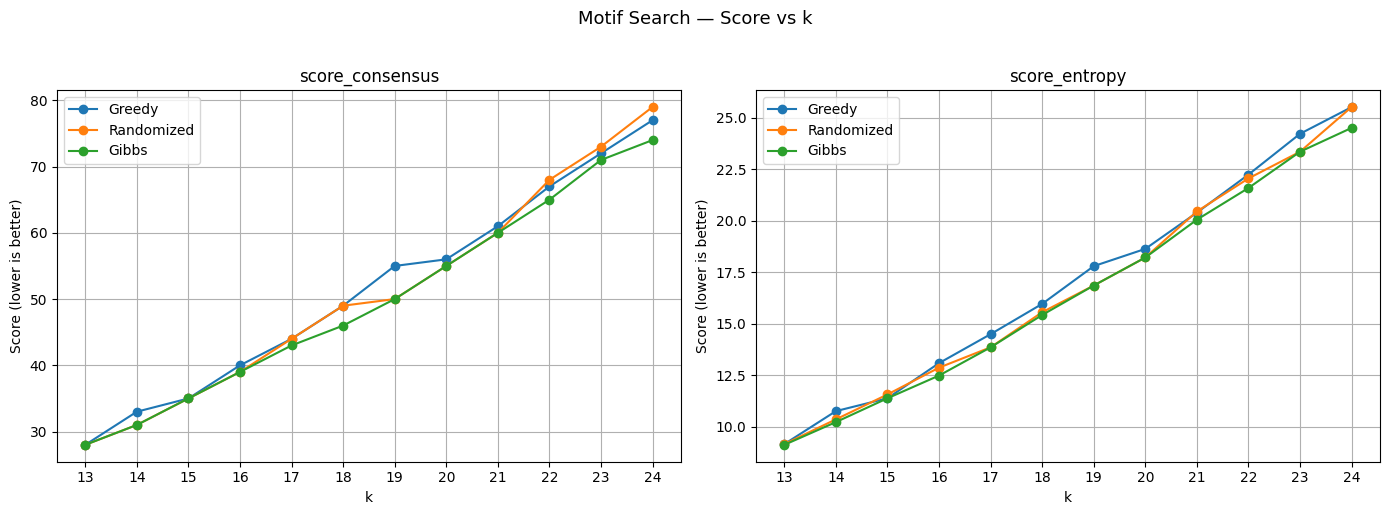

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_fn_names = [fn.__name__ for fn in score_functions]
ks = list(range(K_START, K_END))

for ax, score_name in zip(axes, score_fn_names):
    greedy_scores     = [greedy_results[score_name][k][1]     for k in ks]
    randomized_scores = [randomized_results[score_name][k][1] for k in ks]
    gibbs_scores      = [gibbs_results[score_name][k][1]      for k in ks]

    ax.plot(ks, greedy_scores,     marker='o', label='Greedy')
    ax.plot(ks, randomized_scores, marker='o', label='Randomized')
    ax.plot(ks, gibbs_scores,      marker='o', label='Gibbs')

    ax.set_title(score_name)
    ax.set_xlabel("k")
    ax.set_ylabel("Score (lower is better)")
    ax.set_xticks(ks)
    ax.legend()
    ax.grid(True)

plt.suptitle("Motif Search — Score vs k", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Visualization of the normalized scores.

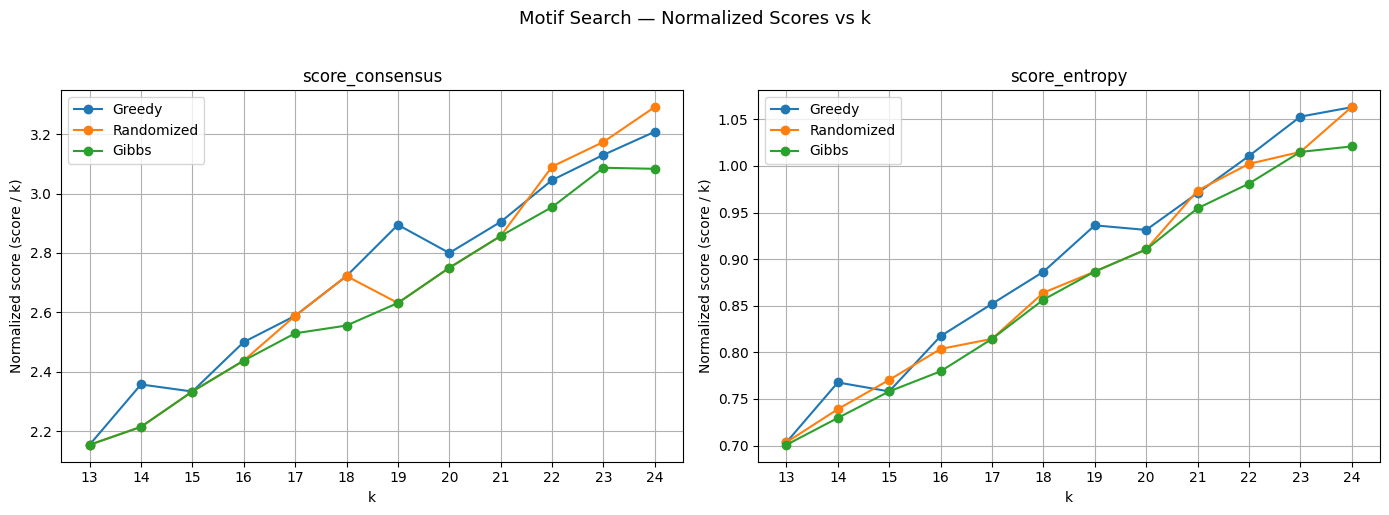

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score_fn_names = [fn.__name__ for fn in score_functions]

for ax, score_name in zip(axes, score_fn_names):
    ks = list(range(K_START, K_END))

    greedy_scores     = [greedy_results[score_name][k][1] / k     for k in ks]
    randomized_scores = [randomized_results[score_name][k][1] / k for k in ks]
    gibbs_scores      = [gibbs_results[score_name][k][1] / k      for k in ks]

    ax.plot(ks, greedy_scores,     marker='o', label='Greedy')
    ax.plot(ks, randomized_scores, marker='o', label='Randomized')
    ax.plot(ks, gibbs_scores,      marker='o', label='Gibbs')

    ax.set_title(score_name)
    ax.set_xlabel("k")
    ax.set_ylabel("Normalized score (score / k)")
    ax.set_xticks(ks)
    ax.legend()
    ax.grid(True)

plt.suptitle("Motif Search — Normalized Scores vs k", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()